# K-Fold Validation — CLAP Classico vs ResiDualCLAP

Questo notebook esegue la K-Fold cross-validation su tutti i dataset
e produce i plot comparativi finali.

## 0. Configurazione globale
Imposta qui tutti i parametri prima di eseguire il notebook.

In [1]:
# ============================================================
# CONFIGURAZIONE — modifica questi valori
# ============================================================

# --- Device ---
USE_CUDA = True

# --- Percorsi ---
MODEL_PATH  = None          # None = download automatico da HuggingFace
OUTPUT_DIR  = 'kfolds'      # Directory dove salvare i risultati
DATA_ROOT   = '../data'      # Root dei dataset

# --- K-Fold ---
N_FOLDS     = 2             # Numero di fold
SEED        = 42            # Seed globale (tutto deterministico)
N_SAMPLES   = 100          # Campioni per dataset (campionamento stratificato)

# --- PCA (solo ResiDual) ---
N_PCA_SAMPLES   = 10       # Quanti campioni usare per il fitting PCA
PCA_BATCH_SIZE  = 1        # Batch size durante la raccolta PCA

# --- Lambda optimization (solo ResiDual) ---
LAMBDA_BATCH_SIZE = 1      # Batch size durante ottimizzazione λ
MAX_EPOCHS        = 2      # Epoche massime
PATIENCE          = 1       # Early stopping patience
LR                = 1e-2    # Learning rate per λ
DECAY             = 1e-2    # Weight decay per AdamW
VARIANCE_THRESH   = 0.95    # Soglia varianza cumulata per scelta k nelle PCA

# --- Valutazione ---
EVAL_BATCH_SIZE = 1        # Batch size per la valutazione zero-shot

# --- ResiDual config ---
RESIDUAL_CONFIG = {
    'target_layers':      [2, 3],
    'variance_threshold': VARIANCE_THRESH,
}

# 1. Import e setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import json
from pathlib import Path
from tqdm.notebook import tqdm

from CLAPWrapper import CLAPWrapper
from datasets.esc50  import ESC50
from datasets.irmas  import IRMAS
from datasets.tinysol    import TinySOL   
from datasets.vocalsound import VocalSound

from models.train_kfold import (
    run_kfold_residual,
    run_kfold_classic,
    load_all_results,
    set_seed,
)

set_seed(SEED)
print(f"CUDA disponibile: {torch.cuda.is_available()}")
print(f"Device: {'cuda' if USE_CUDA and torch.cuda.is_available() else 'cpu'}")

CUDA disponibile: False
Device: cpu


# 2. Caricamento dataset
Ogni dataset viene caricato una volta sola e riutilizzato per entrambe le versioni.

In [3]:
print("Caricamento ESC-50...")
esc50 = ESC50(root=DATA_ROOT, download=True)
print(f"  Campioni: {len(esc50)} | Classi: {len(esc50.classes)}")

print("\nCaricamento IRMAS...")
irmas = IRMAS(root=DATA_ROOT, download=True)
print(f"  Campioni: {len(irmas)} | Classi: {len(irmas.classes)}")

print("\nCaricamento TinySOL...")
tinysol = TinySOL(root=DATA_ROOT, download=True)

print("\nCaricamento VocalSound...")
vocalsound = VocalSound(root=DATA_ROOT, download=True)

# Dizionario dataset_name → dataset object
DATASETS = {
    'ESC50': esc50,
    'IRMAS': irmas,
    'TinySOL':    tinysol,
    'VocalSound': vocalsound,
}

Caricamento ESC-50...
Dataset già presente in ../data/ESC-50-master, skip download.
Loading audio files


100%|██████████| 2000/2000 [00:00<00:00, 15127.99it/s]


✓ Cache di validazione trovata (2026-04-01T21:46:58.127961): 2000 validi, 0 corrotti. Skip validazione.
  Campioni: 2000 | Classi: 50

Caricamento IRMAS...
Dataset già presente in ../data/IRMAS-TrainingData, skip download.
Loading IRMAS audio files...


100%|██████████| 11/11 [00:00<00:00, 154.69it/s]


  Totale campioni caricati: 6705
✓ Cache di validazione trovata (2026-04-09T18:59:59.216527): 6705 validi, 0 corrotti. Skip validazione.
  Campioni: 6705 | Classi: 11

Caricamento TinySOL...
Dataset già presente in ../data/TinySOL
Loading audio files


100%|██████████| 2913/2913 [00:00<00:00, 15880.91it/s]


✓ Cache di validazione trovata (2026-04-01T23:54:22.189250): 2913 validi, 0 corrotti. Skip validazione.

Caricamento VocalSound...
Dataset già presente in ../data/VocalSound
Loading audio files


100%|██████████| 21024/21024 [00:01<00:00, 15518.14it/s]


✓ Cache di validazione trovata (2026-04-02T01:44:11.836275): 20985 validi, 39 corrotti. Skip validazione.


# 3. K-Fold — CLAP Classico
Per ogni dataset esegue la K-Fold zero-shot evaluation senza ottimizzazione.

In [14]:
# Carica il modello CLAP classico
print("Caricamento CLAP classico...")
clap_classic = CLAPWrapper(
    model_fp = MODEL_PATH,
    version  = '2023',
    use_cuda = USE_CUDA,
    type     = 'classic',
)
print("  ✓ Modello caricato")

Caricamento CLAP classico...
  ✓ Modello caricato


In [15]:
# Esegui K-Fold classico su tutti i dataset
for dataset_name, dataset in DATASETS.items():
    print(f"\n{'='*60}")
    print(f"  Dataset: {dataset_name}")
    print(f"{'='*60}")

    run_kfold_classic(
        clap_wrapper    = clap_classic,
        dataset         = dataset,
        dataset_name    = dataset_name,
        n_folds         = N_FOLDS,
        n_samples       = N_SAMPLES,
        seed            = SEED,
        eval_batch_size = EVAL_BATCH_SIZE,
        use_cuda        = USE_CUDA,
        output_dir      = OUTPUT_DIR,
    )


  Dataset: ESC50

[Classic K-Fold] Calcolo text embeddings...


  Encoding text:   0%|          | 0/2 [00:00<?, ?it/s]

[Classic] ESC50 K-Fold:   0%|          | 0/2 [00:00<?, ?it/s]

  [Fold 1/2] Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

  Fold 1/2 | accuracy: 0.9000


...

[Classic] VocalSound K-Fold:   0%|          | 0/2 [00:00<?, ?it/s]

  [Fold 1/2] Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

  Fold 1/2 | accuracy: 0.7400


  [Fold 2/2] Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

  Fold 2/2 | accuracy: 0.7600

[Classic] VocalSound → mean=0.7500 ± 0.0100
  Risultati salvati in kfolds/VocalSound/classic_results.json


# 4. K-Fold — ResiDualCLAP
Per ogni dataset esegue K-Fold con fitting PCA e ottimizzazione λ.

In [4]:
# Carica il modello ResiDualCLAP
# NOTA: viene creato un nuovo wrapper per ogni dataset per resettare i pesi λ
print("Il modello ResiDual verrà caricato per ogni dataset (reset λ)")

Il modello ResiDual verrà caricato per ogni dataset (reset λ)


In [4]:
for dataset_name, dataset in DATASETS.items():
    print(f"\n{'='*60}")
    print(f"  Dataset: {dataset_name}")
    print(f"{'='*60}")

    # Ricarichiamo il modello ad ogni dataset per avere λ freschi
    clap_residual = CLAPWrapper(
        model_fp        = MODEL_PATH,
        version         = '2023',
        use_cuda        = USE_CUDA,
        type            = 'residual',
        residual_config = RESIDUAL_CONFIG,
    )

    run_kfold_residual(
        clap_wrapper        = clap_residual,
        dataset             = dataset,
        dataset_name        = dataset_name,
        residual_config     = RESIDUAL_CONFIG,
        n_folds             = N_FOLDS,
        n_samples           = N_SAMPLES,
        n_pca_samples       = N_PCA_SAMPLES,
        seed                = SEED,
        pca_batch_size      = PCA_BATCH_SIZE,
        lambda_batch_size   = LAMBDA_BATCH_SIZE,
        max_epochs          = MAX_EPOCHS,
        patience            = PATIENCE,
        lr                  = LR,
        wd                  = DECAY,
        variance_threshold  = VARIANCE_THRESH,
        eval_batch_size     = EVAL_BATCH_SIZE,
        use_cuda            = USE_CUDA,
        output_dir          = OUTPUT_DIR,
    )

    del clap_residual  # libera memoria


  Dataset: ESC50

[ResiDual K-Fold] Calcolo text embeddings...


  Encoding text:   0%|          | 0/2 [00:00<?, ?it/s]

[ResiDual] ESC50 K-Fold:   0%|          | 0/2 [00:00<?, ?it/s]


  Fold 1/2
  Train: 50 | PCA: 10 | Lambda: 40 | Test: 50

  [Fold 1] Fase 1: Fitting PCA...


[ResiDual] Raccolta per PCA:   0%|          | 0/10 [00:00<?, ?it/s]

...

  Epoch   1/2 | acc=0.6250 | best=-1.0000


    Optimizing λ:   0%|          | 0/40 [00:00<?, ?it/s]

  Epoch   2/2 | acc=0.7000 | best=0.6250
[ResiDual] Best accuracy: 0.7000 @ epoch 2

  [Fold 2] Fase 3: Valutazione zero-shot...


  [Fold 2/2] Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]


  ✓ Fold 2 accuracy: 0.7200

[ResiDual] VocalSound → mean=0.7200 ± 0.0000
  Risultati salvati in kfolds/VocalSound/residual_results.json


# 5. Caricamento risultati e plot comparativi

In [5]:
all_results = load_all_results(OUTPUT_DIR)
print("Dataset con risultati:")
for name, res in all_results.items():
    classic_acc  = res['classic']['mean_accuracy']  if res['classic']  else 'N/A'
    residual_acc = res['residual']['mean_accuracy'] if res['residual'] else 'N/A'
    print(f"  {name:<15} classic={classic_acc:.4f}   residual={residual_acc:.4f}")

Dataset con risultati:
  ESC50           classic=0.9200   residual=0.9000
  IRMAS           classic=0.6200   residual=0.7100
  TinySOL         classic=0.3400   residual=0.5800
  VocalSound      classic=0.7500   residual=0.7600


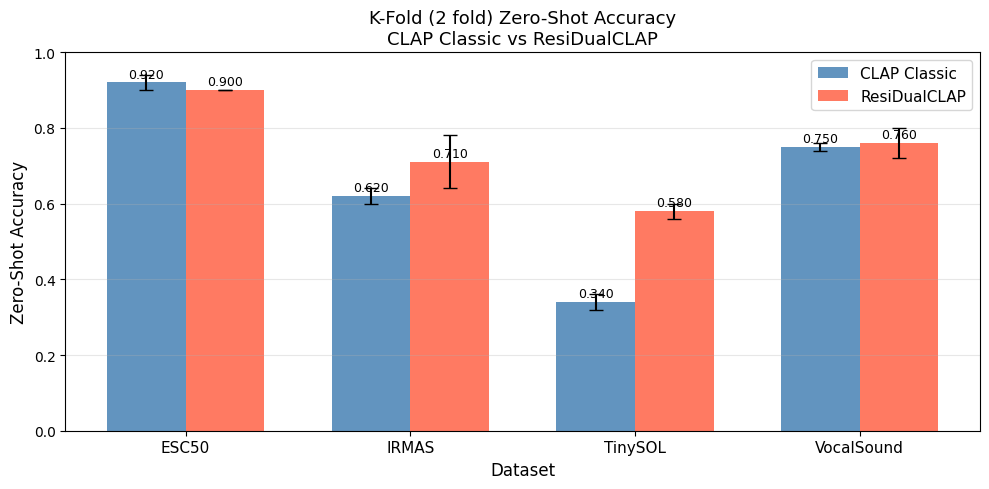

In [6]:
# ============================================================
# PLOT 1: Bar chart — accuracy per dataset
# ============================================================

dataset_names = list(all_results.keys())
classic_means  = [all_results[n]['classic']['mean_accuracy']  if all_results[n]['classic']  else 0 for n in dataset_names]
classic_stds   = [all_results[n]['classic']['std_accuracy']   if all_results[n]['classic']  else 0 for n in dataset_names]
residual_means = [all_results[n]['residual']['mean_accuracy'] if all_results[n]['residual'] else 0 for n in dataset_names]
residual_stds  = [all_results[n]['residual']['std_accuracy']  if all_results[n]['residual'] else 0 for n in dataset_names]

x     = np.arange(len(dataset_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, classic_means,  width, yerr=classic_stds,
               label='CLAP Classic', color='steelblue',  capsize=5, alpha=0.85)
bars2 = ax.bar(x + width/2, residual_means, width, yerr=residual_stds,
               label='ResiDualCLAP', color='tomato', capsize=5, alpha=0.85)

# Etichette valore sopra le barre
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
            f'{h:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
            f'{h:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Dataset', fontsize=12)
ax.set_ylabel('Zero-Shot Accuracy', fontsize=12)
ax.set_title(f'K-Fold ({N_FOLDS} fold) Zero-Shot Accuracy\nCLAP Classic vs ResiDualCLAP', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(dataset_names, fontsize=11)
ax.set_ylim(0, min(1.0, max(max(classic_means), max(residual_means)) + 0.15))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plot_bar_accuracy.png', dpi=150)
plt.show()

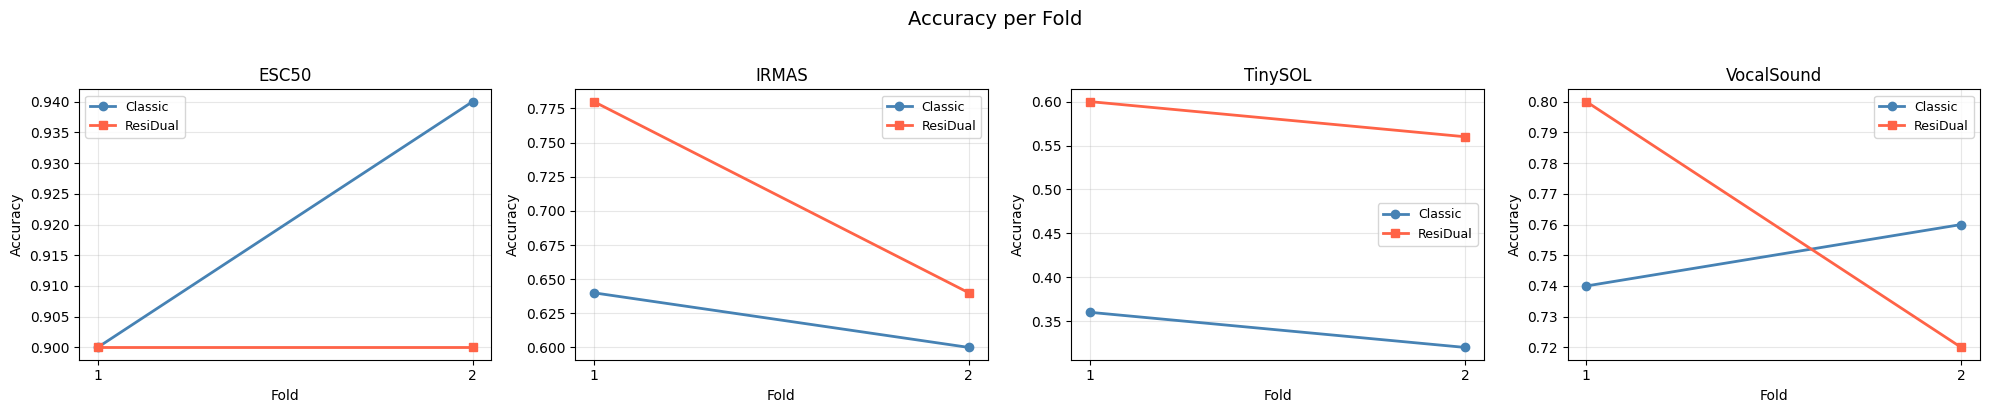

In [7]:
# ============================================================
# PLOT 2: Fold-by-fold accuracy — per ogni dataset
# ============================================================

n_datasets = len(dataset_names)
fig, axes  = plt.subplots(1, n_datasets, figsize=(5 * n_datasets, 4), sharey=False)
if n_datasets == 1:
    axes = [axes]

for ax, name in zip(axes, dataset_names):
    res = all_results[name]
    fold_ids = list(range(1, N_FOLDS + 1))

    if res['classic']:
        classic_fold_accs = [f['accuracy'] for f in res['classic']['folds']]
        ax.plot(fold_ids, classic_fold_accs, 'o-', color='steelblue',
                label='Classic', linewidth=2, markersize=6)

    if res['residual']:
        residual_fold_accs = [f['accuracy'] for f in res['residual']['folds']]
        ax.plot(fold_ids, residual_fold_accs, 's-', color='tomato',
                label='ResiDual', linewidth=2, markersize=6)

    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Fold', fontsize=10)
    ax.set_ylabel('Accuracy', fontsize=10)
    ax.set_xticks(fold_ids)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Accuracy per Fold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plot_folds_accuracy.png', dpi=150)
plt.show()

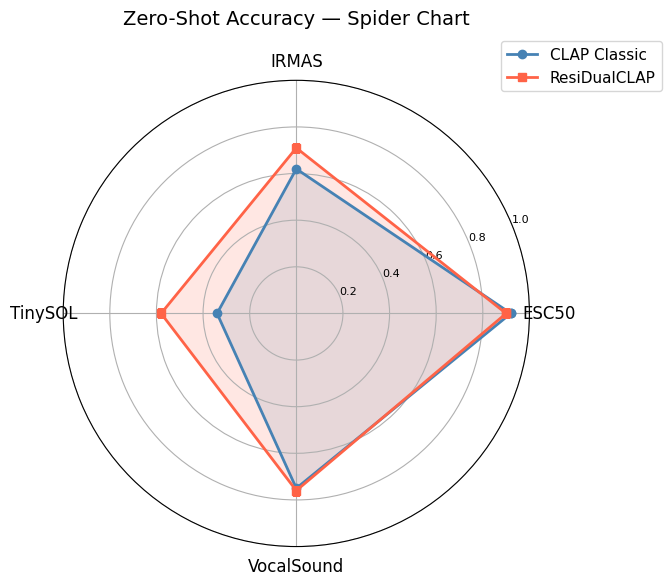

In [8]:
# ============================================================
# PLOT 3: Spider/Radar chart — accuracy per dataset
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

labels = dataset_names
N      = len(labels)

if N < 3:
    print("Spider chart richiede almeno 3 dataset. Aggiungere altri dataset.")
else:
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # chiudi il poligono

    classic_vals  = classic_means  + [classic_means[0]]
    residual_vals = residual_means + [residual_means[0]]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    ax.plot(angles, classic_vals,  'o-', color='steelblue', linewidth=2, label='CLAP Classic')
    ax.fill(angles, classic_vals,  color='steelblue', alpha=0.15)

    ax.plot(angles, residual_vals, 's-', color='tomato',    linewidth=2, label='ResiDualCLAP')
    ax.fill(angles, residual_vals, color='tomato',    alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
    ax.set_title('Zero-Shot Accuracy — Spider Chart', fontsize=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/plot_spider_accuracy.png', dpi=150)
    plt.show()

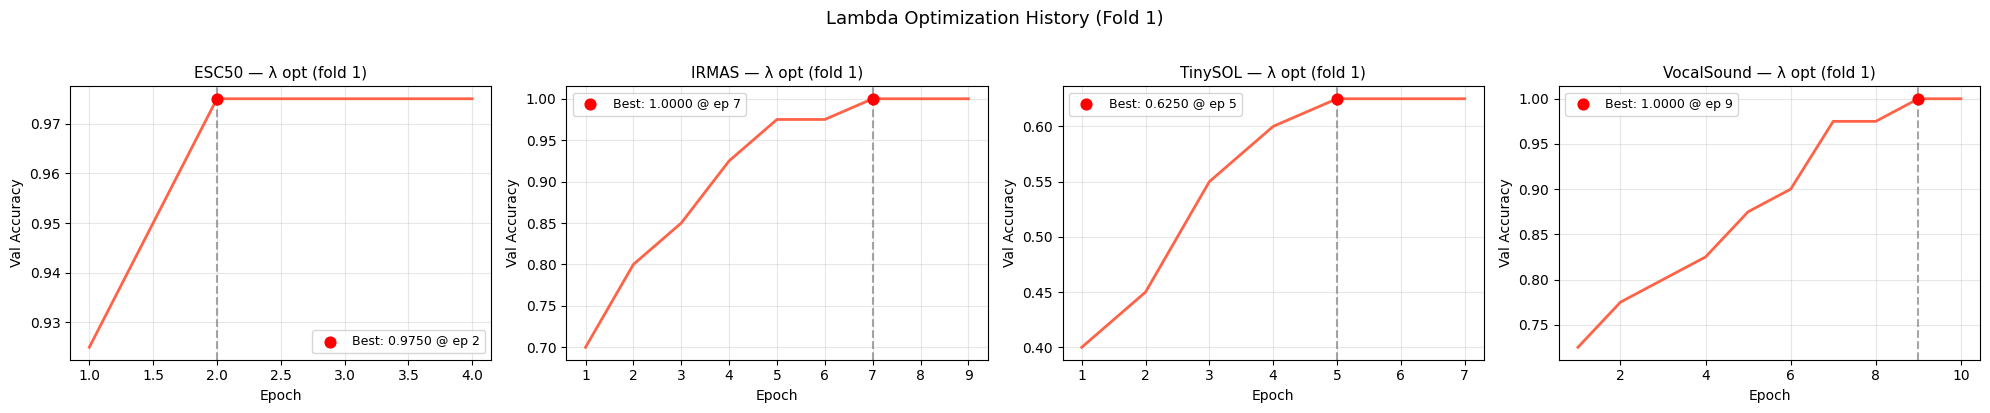

In [9]:
# ============================================================
# PLOT 4: Lambda optimization history (per ogni dataset, primo fold)
# ============================================================

fig, axes = plt.subplots(1, n_datasets, figsize=(5 * n_datasets, 4), sharey=False)
if n_datasets == 1:
    axes = [axes]

for ax, name in zip(axes, dataset_names):
    res = all_results[name]
    if res['residual'] and res['residual']['folds']:
        history = res['residual']['folds'][0].get('lambda_history', [])
        if history:
            ax.plot(range(1, len(history) + 1), history, color='tomato', linewidth=2)
            best_epoch = res['residual']['folds'][0]['best_lambda_epoch']
            best_acc   = res['residual']['folds'][0]['best_lambda_acc']
            ax.axvline(best_epoch, linestyle='--', color='gray', alpha=0.7)
            ax.scatter([best_epoch], [best_acc], color='red', zorder=5, s=60,
                       label=f'Best: {best_acc:.4f} @ ep {best_epoch}')
            ax.legend(fontsize=9)

    ax.set_title(f'{name} — λ opt (fold 1)', fontsize=11)
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Val Accuracy', fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('Lambda Optimization History (Fold 1)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plot_lambda_history.png', dpi=150)
plt.show()

In [10]:
# ============================================================
# Riepilogo finale testuale
# ============================================================

print("\n" + "="*55)
print("  RIEPILOGO FINALE")
print("="*55)
print(f"{'Dataset':<15} {'Classic':>10} {'ResiDual':>10} {'Delta':>8}")
print("-"*55)
for name in dataset_names:
    c = all_results[name]['classic']['mean_accuracy']  if all_results[name]['classic']  else 0
    r = all_results[name]['residual']['mean_accuracy'] if all_results[name]['residual'] else 0
    delta = r - c
    sign  = '+' if delta >= 0 else ''
    print(f"{name:<15} {c:>10.4f} {r:>10.4f} {sign+f'{delta:.4f}':>8}")
print("="*55)


  RIEPILOGO FINALE
Dataset            Classic   ResiDual    Delta
-------------------------------------------------------
ESC50               0.9200     0.9000  -0.0200
IRMAS               0.6200     0.7100  +0.0900
TinySOL             0.3400     0.5800  +0.2400
VocalSound          0.7500     0.7600  +0.0100
